# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [9]:
import pandas as pd
import numpy as np

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('iris.csv')
print(df.head())

# =========================
# CEK KOLOM
# =========================
print(df.columns)

# =========================
# PREPROCESSING
# =========================
# Buang kolom yang tidak diperlukan (Id)
X = df.drop(['Id', 'Species'], axis=1)
y = df['Species']

# =========================
# ENCODING LABEL
# =========================
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

# =========================
# SPLIT DATA
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# SCALING (PENTING UNTUK KNN)
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# MODEL K-NN
# =========================
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# =========================
# PREDIKSI
# =========================
y_pred = knn.predict(X_test)

# =========================
# EVALUASI
# =========================
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')
Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00       

### Exploratory Data Analysis

In [6]:
import pandas as pd

df = pd.read_csv('iris.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
# Statistik numerik
print(df.describe())

# Info dataset
df.info()

# Cek missing value
print(df.isnull().sum())

# Cek jumlah tiap kelas
print(df['Species'].value_counts())

               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    

C:\Users\acer\AppData\Local\Temp\ipykernel_9732\3511824936.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species', data=df, palette='RdBu_r')


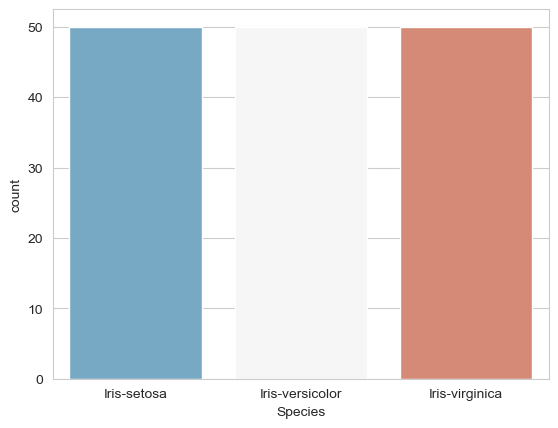

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
sns.countplot(x='Species', data=df, palette='RdBu_r')

plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_9732\1830997431.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species', data=df, palette='RdBu_r')


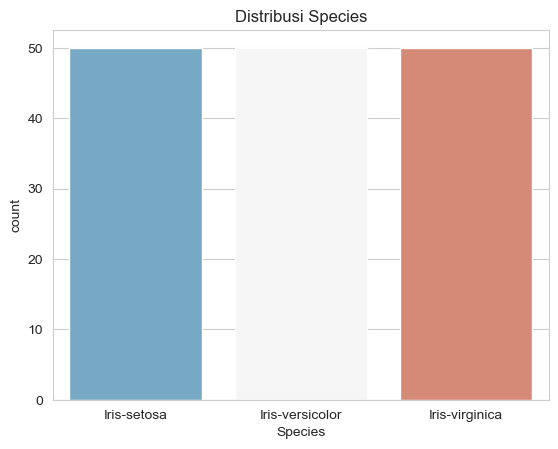

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
sns.countplot(x='Species', data=df, palette='RdBu_r')

plt.title('Distribusi Species')
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_9732\739999122.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species', data=df, palette='rainbow')


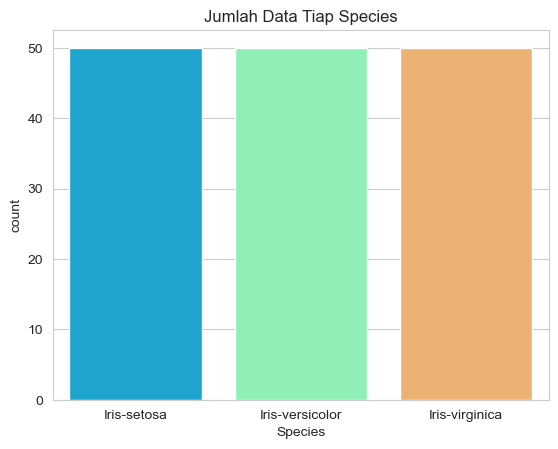

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
sns.countplot(x='Species', data=df, palette='rainbow')

plt.title('Jumlah Data Tiap Species')
plt.show()

                    Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  \
Species                                                              
Iris-setosa       25.5          5.006         3.418          1.464   
Iris-versicolor   75.5          5.936         2.770          4.260   
Iris-virginica   125.5          6.588         2.974          5.552   

                 PetalWidthCm  
Species                        
Iris-setosa             0.244  
Iris-versicolor         1.326  
Iris-virginica          2.026  


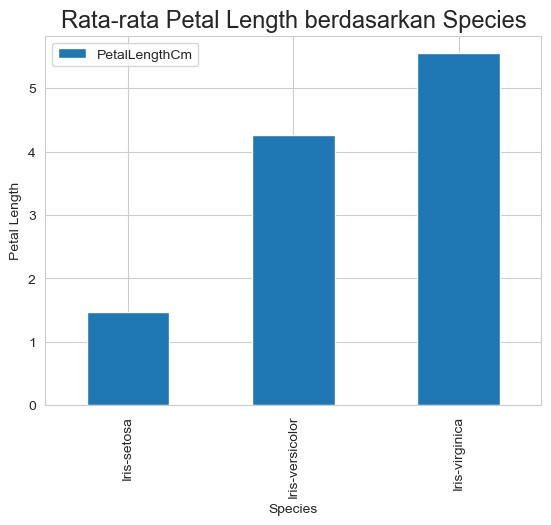

In [12]:
import matplotlib.pyplot as plt

# Rata-rata fitur berdasarkan Species
f_species = df.groupby('Species').mean()

# Tampilkan dalam bentuk DataFrame
print(f_species)

# Plot (contoh: rata-rata Petal Length)
f_species[['PetalLengthCm']].plot.bar()

plt.title("Rata-rata Petal Length berdasarkan Species", fontsize=17)
plt.ylabel("Petal Length")
plt.show()

In [13]:
import pandas as pd

# Load data (PERHATIKAN huruf besar kecil)
df = pd.read_csv('Iris.csv')

# Info dataset
df.info()

# Lihat data awal
print(df.head())

# =========================
# EDA SEDERHANA
# =========================

# Statistik
print(df.describe())

# Cek missing value
print(df.isnull().sum())

# Jumlah tiap species
print(df['Species'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
               Id  S

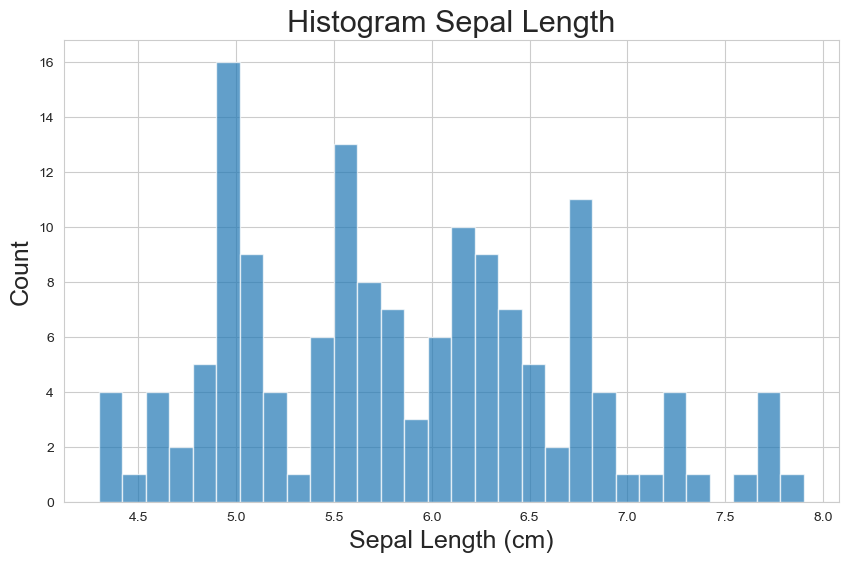

In [15]:
import matplotlib.pyplot as plt

plt.xlabel("Sepal Length (cm)", fontsize=18)
plt.ylabel("Count", fontsize=18)
plt.title("Histogram Sepal Length", fontsize=22)

df['SepalLengthCm'].hist(bins=30, alpha=0.7, figsize=(10,6))

plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_9732\2932637916.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Species', y='SepalLengthCm', data=df, palette='winter')


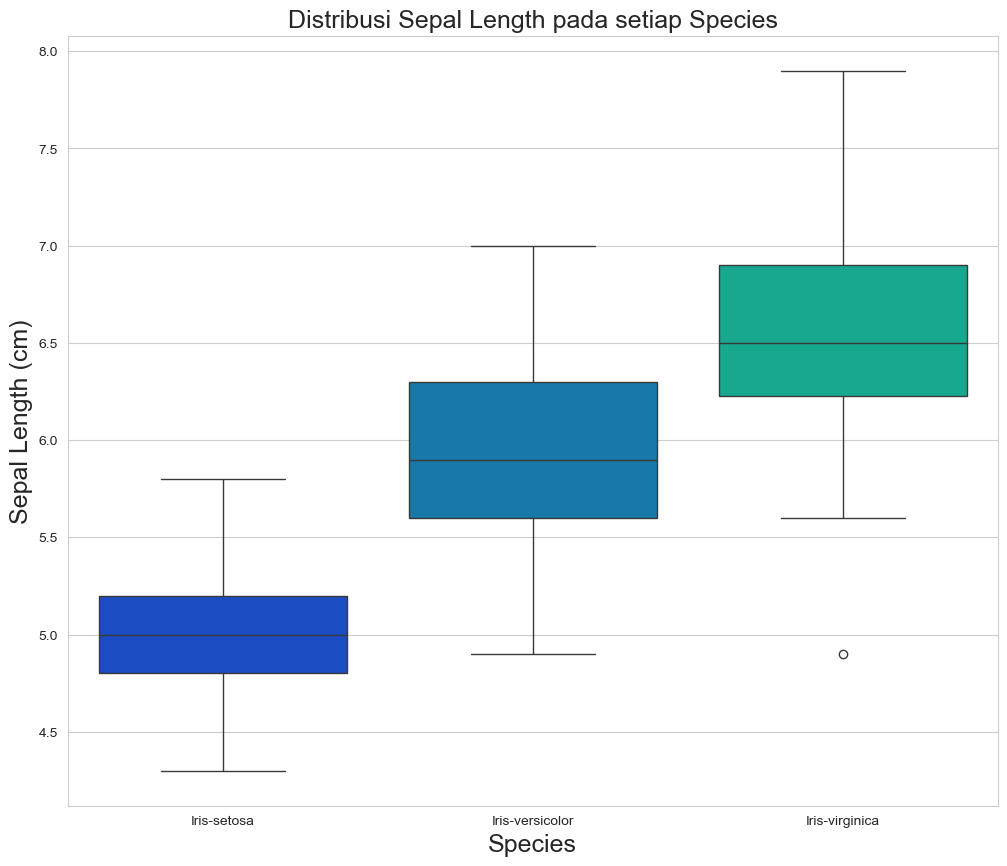

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

plt.xlabel("Species", fontsize=18)
plt.ylabel("Sepal Length (cm)", fontsize=18)

sns.boxplot(x='Species', y='SepalLengthCm', data=df, palette='winter')

plt.title("Distribusi Sepal Length pada setiap Species", fontsize=18)
plt.show()

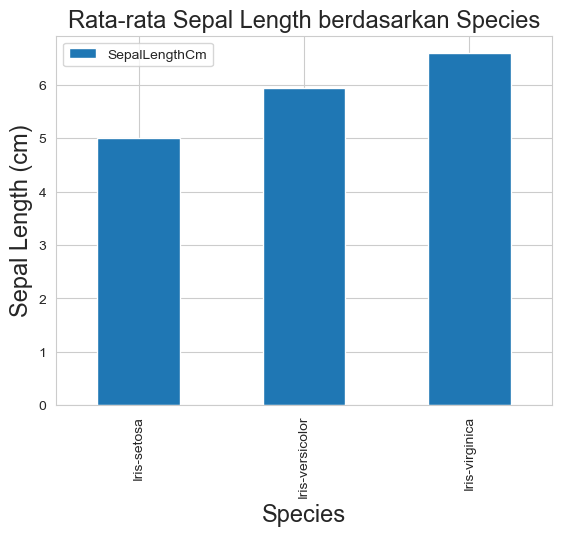

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Rata-rata fitur berdasarkan Species
f_species = df.groupby('Species')['SepalLengthCm'].mean()

# Ubah ke DataFrame
f_species = pd.DataFrame(f_species)

# Plot
f_species.plot.bar(y='SepalLengthCm')

plt.title("Rata-rata Sepal Length berdasarkan Species", fontsize=17)
plt.ylabel("Sepal Length (cm)", fontsize=17)
plt.xlabel("Species", fontsize=17)

plt.show()

### Fitur Engineering

In [21]:
# Hitung rata-rata per species
mean_values = df.groupby('Species')['SepalLengthCm'].mean()

# Function untuk isi missing value
def impute_sepal_length(cols):
    value = cols[0]
    species = cols[1]

    if pd.isnull(value):
        return mean_values[species]
    else:
        return value

In [23]:
df['SepalLengthCm'] = df[['SepalLengthCm', 'Species']].apply(impute_sepal_length, axis=1)

C:\Users\acer\AppData\Local\Temp\ipykernel_9732\393214999.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  value = cols[0]
C:\Users\acer\AppData\Local\Temp\ipykernel_9732\393214999.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  species = cols[1]


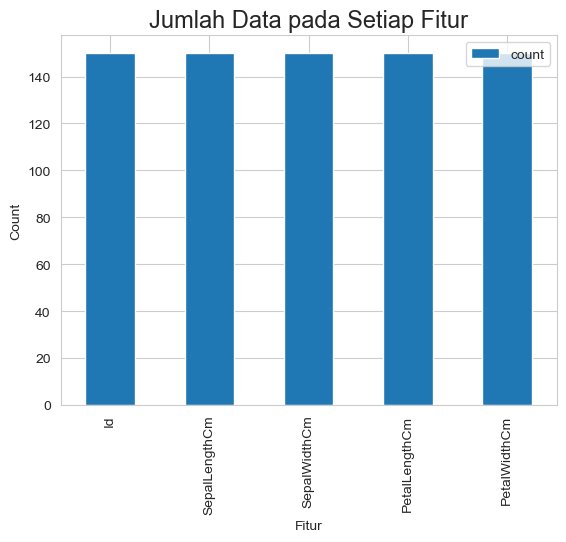

In [24]:
import matplotlib.pyplot as plt

# Statistik deskriptif
d = df.describe()

# Transpose biar kebaca per fitur
dT = d.T

# Plot jumlah data (count)
dT.plot.bar(y='count')

plt.title("Jumlah Data pada Setiap Fitur", fontsize=17)
plt.ylabel("Count")
plt.xlabel("Fitur")

plt.show()

In [26]:
# Tidak ada kolom Cabin, jadi langsung lanjut
df_clean = df.copy()

# Drop missing value kalau ada (optional)
df_clean.dropna(inplace=True)

# Lihat hasil
print(df_clean.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [27]:
# Drop kolom yang tidak diperlukan
df.drop(['Id'], axis=1, inplace=True)

# Lihat hasil
print(df.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa


In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode kolom target (Species)
df['Species'] = le.fit_transform(df['Species'])

# Lihat hasil
print(df.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0            5.1           3.5            1.4           0.2        0
1            4.9           3.0            1.4           0.2        0
2            4.7           3.2            1.3           0.2        0
3            4.6           3.1            1.5           0.2        0
4            5.0           3.6            1.4           0.2        0


### Training

In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['Species'])

X = df.drop('Species', axis=1)

In [31]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (120, 4)
Test shape: (30, 4)


# **KNN**

In [32]:
from sklearn.neighbors import KNeighborsClassifier
clf1 = KNeighborsClassifier()

clf1.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [33]:
y_pred = clf1.predict(X_test)

### Evaluation

In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 1.00
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [35]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred1 = clf2.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred1) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred1))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred1))

Akurasi Model KNN: 1.00
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### jika ingin mencoba semua parameter

In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
11  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.958333   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.950000   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.950000   
0   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.950000   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.950000   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.950000   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.950000   
10  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.950000   
4   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.941667   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.941667   
2   {'metric': 'euclidean', 'n_neighbors

In [38]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [39]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}


In [40]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  1.00
Presisi:  1.00
Recall:   1.00
F1-Score: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [43]:
import numpy as np

print("\n=== Prediksi Data Baru ===")

# Data baru (harus 4 fitur sesuai Iris)
# urutan: SepalLength, SepalWidth, PetalLength, PetalWidth
new_data = np.array([[6.0, 3.0, 5.0, 2.0]])

# Scaling (WAJIB kalau sebelumnya pakai scaler)
new_data_scaled = scaler.transform(new_data)

# Prediksi
prediction = best_model.predict(new_data_scaled)

# Tampilkan hasil
print("Hasil prediksi (angka):", prediction[0])

# Kalau pakai LabelEncoder
try:
    print("Hasil prediksi (label):", le.inverse_transform(prediction)[0])
except:
    pass


=== Prediksi Data Baru ===
Hasil prediksi (angka): 2
Hasil prediksi (label): 2


c:\Users\acer\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
